# Исследовательский анализ рынка общественного питания в г. Екатеринбурге
- Автор: Куколкина Алена
- Дата: 24.06.2026

Рынок общественного питания крупных городов характеризуется высокой плотностью заведений, жёсткой конкуренцией и значительными объёмами инвестиций на старте. Принимая решение об открытии нового кафе или ресторана, инвестор сталкивается с тремя фундаментальными вопросами: **где разместить** заведение, **какую кухню** и **ценовой сегмент** выбрать, и какую **прибыль** можно ожидать. Интуитивные решения в этой сфере сопряжены с высокими рисками: ошибка в локации или концепции способна привести к убыткам и закрытию уже в первый год работы. В то же время открытые данные о существующих заведениях, их характеристиках и отзывах посетителей содержат значительный потенциал для объективного анализа рыночной ситуации. Однако эти данные рассредоточены, не структурированы и не ориентированы на конечного пользователя – инвестора, не владеющего аналитическими инструментами.

## Введение

**Цель проекта** – разработать интерактивный аналитический дашборд для поддержки принятия инвестиционных решений при открытии заведения общественного питания в крупном городе. Дашборд должен агрегировать и визуализировать данные о 2000 реальных заведениях, дополненные геопространственной и инфраструктурной информацией, и предоставлять инвестору возможность самостоятельно исследовать рынок, выявлять перспективные локации и ниши.

**Исходные данные.** В основе проекта лежит датасет из 2000 заведений общественного питания города Екатеринбурга, включающий название, координаты, категорию, тип кухни, средний чек, рейтинг и количество отзывов. Датасет получен с помощью веб-парсинга открытых данных сайта 2ГИС по состоянию на май 2026 года. Дополнительно привлечены открытые источники пространственных данных. Все вычисления выполнены на Python с использованием библиотек pandas, geopandas, osmnx, pyrosm.

В ходе работы последовательно решены следующие задачи:

* **Извлечение и структурирование данных** – преобразование иерархического JSON-файла 2ГИС в плоскую таблицу с выделением ключевых характеристик заведений (название, адрес, координаты, рубрика, рейтинг, кухни, услуги и пр.).
* **Очистка и предобработка** – фильтрация по городу, удаление дубликатов, обработка пропусков, унификация категориальных признаков (тип заведения, район), нормализация и заполнение поля «кухня» с привлечением данных из меню и списка услуг.
* **Обогащение внешними данными** – загрузка предложений аренды/продажи коммерческой недвижимости (Циан), точек интереса (2ГИС) и остановок транспорта (OpenStreetMap), административных границ районов.
* **Расчёт аналитических метрик** – ценовая категория, байесовский рейтинг, флаг успешности заведения, бинарные признаки востребованных услуг (Wi‑Fi, веранда, бизнес‑ланч, детское меню), количество конкурентов и разнообразие кухонь в радиусе 1 км, расстояние до метро.
* **Анализ коммерческих помещений** – для каждого объекта недвижимости определены плотность конкурентов, средний рейтинг и отзывность вокруг, список отсутствующих кухонь, минимальное расстояние до метро.
* **Агрегация по районам** – вычислены плотность заведений, средний чек, средний рейтинг, разнообразие кухонь, доля точек с парковкой и средняя удалённость от метро; метрики нормированы для построения радарных диаграмм.
* **Выявление свободных ниш** – построена матрица «район × кухня» с индикаторами пустых ниш и платёжеспособности района.
* **Подготовка данных для визуализации** – все итоговые датафреймы сохранены в формате CSV для загрузки в BI-инструмент и построения дашборда.

## Содержание

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Обогащение данных из внешних источников
4. Расчет дополнительных метрик
5. Подготовка данных по административным районам
6. Выгрузка данных для визуализации
7. Выводы

## Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки

import pandas as pd
import numpy as np

# Обработка входящих файлов
import json
import logging
from typing import Any, Dict, List, Optional, Tuple
from pathlib import Path

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Геоанализ
import geopandas as gpd
import osmnx as ox
from pyrosm import OSM
from pyproj import Geod
from shapely.geometry import Point
from sklearn.neighbors import BallTree
from sklearn.metrics.pairwise import haversine_distances

Необходимо преобразовать исходные иерархические JSON-данные о заведениях в плоскую таблицу для последующего анализа.
Из исходного файла загружаем список объектов, исключаем записи нежелательных категорий и для каждого извлекаем фиксированный набор полей: базовую информацию (название, адрес, координаты, рубрику), метрики (рейтинг, количество отзывов, число фото), а также множественные характеристики (кухни, услуги, ассортимент меню), которые собираются из вложенных групп атрибутов.

In [2]:
# -----------------------------------------------------------------------------
# Константы для классификации тегов атрибутов
# -----------------------------------------------------------------------------

# Соответствие между специальными тегами (точечные, не множественные) и
# названиями колонок, в которые они записываются.
SPECIAL_TAGS: Dict[str, str] = {
    'food_service_avg_price': 'avg_bill',
    'food_service_capacity': 'seats',          # "вместимость" сохраняем как seats
}

# Список префиксов тегов, отсортированный по убыванию длины (от наиболее
# специфичных к общим). Это гарантирует, что более длинный префикс проверится
# первым и не будет перехвачен коротким. Каждому префиксу соответствует
# категория (имя будущей колонки для множественных значений).
PREFIX_CATEGORIES: List[Tuple[str, str]] = [
    ('food_service_assortment_assortment_', 'menu_assortment'),  # ассортимент меню
    ('food_service_food_', 'cuisine'),                           # кухни
    ('food_service_', 'services'),                               # прочие услуги
    ('additionally_services_', 'services'),                      # дополнительные услуги
]

# -----------------------------------------------------------------------------
# Вспомогательные функции
# -----------------------------------------------------------------------------

def classify_tag(tag: str) -> Optional[str]:
    """
    Классифицирует тег атрибута и возвращает название категории (колонки),
    в которую должно быть помещено его значение.

    Порядок проверки:
    1. Сначала проверяется таблица SPECIAL_TAGS (точечные теги).
    2. Затем тег проверяется по списку префиксов PREFIX_CATEGORIES
       от наиболее специфичного к общему.

    Если тег не соответствует ни одному правилу, возвращается None.
    """
    if not isinstance(tag, str):
        return None

    # 1. Особые точечные теги (средний чек, вместимость и т.п.)
    if tag in SPECIAL_TAGS:
        return SPECIAL_TAGS[tag]

    # 2. Проверка по префиксам (кухни, услуги, ассортимент меню)
    for prefix, category in PREFIX_CATEGORIES:
        if tag.startswith(prefix):
            return category

    # Неизвестный тег — не обрабатываем
    return None


def extract_flat_record(obj: Dict[str, Any]) -> Dict[str, Any]:
    """
    Извлекает из одного элемента исходного списка плоскую запись
    с нужными полями для дальнейшего анализа.

    Параметры:
        obj : dict
            Исходный словарь с данными заведения.

    Возвращает:
        dict с полями:
            id, name, address, city, district, microdistrict,
            latitude, longitude, type (основная рубрика),
            rating, review_count, photo_count,
            created_at, has_parking,
            avg_bill, seats, cuisine, services, menu_assortment.
    """
    out: Dict[str, Any] = {}

    # -----------------------------------------------------------------
    # Базовые поля
    # -----------------------------------------------------------------
    out['id'] = obj.get('id')
    out['name'] = obj.get('name_ex', {}).get('primary')  # основное название
    out['address'] = obj.get('address_name')

    # -----------------------------------------------------------------
    # Административное деление
    # -----------------------------------------------------------------
    # adm_div содержит вложенные элементы с информацией о городе, районе и т.д.
    adm_items = obj.get('adm_div', [])

    # Город: выбираем элемент с type='city', предпочитая is_default=True.
    city = None
    city_candidates = [item for item in adm_items if item.get('type') == 'city']
    if city_candidates:
        # Ищем город по умолчанию, если нет — берём первый.
        default_city = next(
            (item.get('name') for item in city_candidates if item.get('is_default')), 
            None
        )
        city = default_city if default_city else city_candidates[0].get('name')
    out['city'] = city

    # Район
    district_items = [item.get('name') for item in adm_items if item.get('type') == 'district']
    out['district'] = district_items[0] if district_items else None

    # -----------------------------------------------------------------
    # Координаты
    # -----------------------------------------------------------------
    point = obj.get('point')
    if isinstance(point, dict):
        out['latitude'] = point.get('lat')
        out['longitude'] = point.get('lon')
    else:
        out['latitude'] = None
        out['longitude'] = None

    # -----------------------------------------------------------------
    # Основная рубрика
    # -----------------------------------------------------------------
    rubrics = obj.get('rubrics', [])
    primary_rubric = None
    for rubric in rubrics:
        if rubric.get('kind') == 'primary':
            primary_rubric = rubric.get('name')
            break
    out['type'] = primary_rubric

    # -----------------------------------------------------------------
    # Рейтинг и отзывы
    # -----------------------------------------------------------------
    reviews = obj.get('reviews', {})
    out['rating'] = reviews.get('general_rating')
    out['review_count'] = reviews.get('general_review_count')

    # -----------------------------------------------------------------
    # Внешний контент (фото)
    # -----------------------------------------------------------------
    ext_content = obj.get('external_content', [])
    photo_count = sum(item.get('count', 0) for item in ext_content if isinstance(item, dict))
    out['photo_count'] = photo_count if photo_count > 0 else None

    # -----------------------------------------------------------------
    # Даты
    # -----------------------------------------------------------------
    dates = obj.get('dates', {})
    out['created_at'] = dates.get('created_at')

    # -----------------------------------------------------------------
    # Наличие парковки
    # -----------------------------------------------------------------
    links = obj.get('links', {})
    parking_list = links.get('parking', [])
    out['has_parking'] = len(parking_list) > 0

    # -----------------------------------------------------------------
    # Атрибуты: кухни, услуги, средний чек, вместимость, ассортимент меню
    # -----------------------------------------------------------------
    # Инициализируем поля и временные множества для множественных категорий.
    out['avg_bill'] = None
    out['seats'] = None
    cuisines_set: set = set()
    services_set: set = set()
    menu_assortment_set: set = set()

    # Последовательность обработки важна, чтобы теги меню не попали в услуги.
    for group in obj.get('attribute_groups', []):
        group_name = group.get('name', '')
        attributes = group.get('attributes', [])

        # Специальная обработка группы «Меню»: собираем названия блюд/ассортимента
        # и пропускаем их в общем цикле, чтобы не принять за услуги.
        if group_name == 'Меню':
            for attr in attributes:
                tag = attr.get('tag')
                name = attr.get('name')
                if tag and name and tag.startswith('food_service_assortment_assortment_'):
                    menu_assortment_set.add(name)
            continue   # переходим к следующей группе, атрибуты меню больше не смотрим

        # Общая обработка атрибутов остальных групп.
        for attr in attributes:
            tag = attr.get('tag')
            name = attr.get('name')
            if not tag:
                continue

            category = classify_tag(tag)
            if category is None:
                continue

            # Точечные категории (может перезаписываться последним значением)
            if category == 'avg_bill':
                out['avg_bill'] = name
            elif category == 'seats':
                out['seats'] = name
            # Множественные категории
            elif category == 'cuisine' and name:
                cuisines_set.add(name)
            elif category == 'services' and name:
                services_set.add(name)
            # menu_assortment сюда не попадает, т.к. группа "Меню" уже обработана.

    # Преобразуем множества в строки, разделённые запятой (с сортировкой)
    out['cuisine'] = ', '.join(sorted(cuisines_set)) if cuisines_set else None
    out['services'] = ', '.join(sorted(services_set)) if services_set else None
    out['menu_assortment'] = (
        ', '.join(sorted(menu_assortment_set)) if menu_assortment_set else None
    )

    return out


def load_dataframe_from_json(file_path: str) -> pd.DataFrame:
    """
    Загружает данные из JSON-файла, фильтрует ненужные категории
    и преобразует каждую запись в плоскую структуру с помощью extract_flat_record.

    Параметры:
        file_path : str
            Путь к JSON-файлу с кодировкой UTF-8 (с BOM или без).

    Возвращает:
        pd.DataFrame с плоскими записями.

    Исключения:
        ValueError, если корневой элемент не является списком.
    """
    logger = logging.getLogger(__name__)

    with open(file_path, 'r', encoding='utf-8-sig') as f:
        data = json.load(f)

    if not isinstance(data, list):
        raise ValueError("Корневой элемент JSON должен быть списком")

    records = []
    skipped = 0
    for item in data:
        # Пропускаем заведения, относящиеся к категории computer_services
        if item.get('poi_category') == 'computer_services':
            skipped += 1
            continue

        try:
            records.append(extract_flat_record(item))
        except Exception as e:
            logger.warning("Ошибка при обработке записи id=%s: %s",
                           item.get('id', 'неизвестно'), e)

    if skipped:
        logger.info("Пропущено записей (computer_services): %d", skipped)
    return pd.DataFrame(records)


# -----------------------------------------------------------------------------
# Основной блок выполнения
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

    FILE_PATH = 'C:/Users/111/Desktop/Projects/rest_project.json'
    df = load_dataframe_from_json(FILE_PATH)
    print(f"Загружено {len(df)} записей")
df.head()

INFO: Пропущено записей (computer_services): 37


Загружено 2036 записей


,id,name,address,city,district,latitude,longitude,type,rating,review_count,photo_count,created_at,has_parking,avg_bill,seats,cuisine,services,menu_assortment
0,70000001037022549_434333444df5eA8d2J7H1J2JHGII...,#НаМангале,"Волгоградская улица, 47в/1",Екатеринбург,Ленинский район,56.804064,60.575768,Быстрое питание,4.7,92.0,17.0,2019-06-14T00:00:00Z,False,Чек 250 ₽,До 3 мест,NaN,Заказ навынос,"Картофель-фри, На гриле, Наггетсы, Шаурма, Шашлык"
1,70000001068094881_434333444df5eA8d2J7H1J2JHGII...,13 шаверм,NaN,Екатеринбург,Верх-Исетский район,56.844782,60.573417,Быстрое питание,2.9,129.0,15.0,NaN,False,Чек 300 ₽,NaN,NaN,"Заказ навынос, Шавермы",Шаурма
2,70000001030431118_434333444df5eA8d2J7H1J2JHGII...,Asia,"улица Попова, 1Б/1",Екатеринбург,Ленинский район,56.835239,60.594022,Быстрое питание,4.5,191.0,35.0,NaN,False,Чек 200 ₽,До 25 мест,Восточная кухня,"Автокафе, Заказ навынос","Лагман, Люля-кебаб, Плов, Салаты, Самса, Супы,..."
3,70000001080045549_434333444df5eA8d2J7H1J2JHGII...,Bazar express,"проспект Космонавтов, 108д",Екатеринбург,Орджоникидзевский район,56.915621,60.614418,Быстрое питание,2.0,41.0,9.0,NaN,True,Чек 300 ₽,NaN,Восточная кухня,"Бесплатный Wi-Fi, Бизнес-ланч, Заказ навынос, ...","Картофель-фри, Лагман, Манты, На гриле, Самса,..."
4,70000001047253993_434333444df5eA8d2J7H1J2JHGII...,Beresta,"Красноармейская улица, 1",Екатеринбург,Октябрьский район,56.837269,60.616194,Столовые,4.1,83.0,21.0,NaN,True,Чек 300 ₽,До 130 мест,NaN,"Заказ навынос, Поминальные обеды, Проведение б...",NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2036 entries, 0 to 2035
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2036 non-null   str    
 1   name             2035 non-null   str    
 2   address          1922 non-null   str    
 3   city             1972 non-null   str    
 4   district         1767 non-null   str    
 5   latitude         2034 non-null   float64
 6   longitude        2034 non-null   float64
 7   type             2035 non-null   str    
 8   rating           1998 non-null   float64
 9   review_count     1998 non-null   float64
 10  photo_count      2013 non-null   float64
 11  created_at       794 non-null    str    
 12  has_parking      2036 non-null   bool   
 13  avg_bill         2033 non-null   str    
 14  seats            1506 non-null   str    
 15  cuisine          929 non-null    str    
 16  services         1943 non-null   str    
 17  menu_assortment  1689 non

### Описание данных

**id** - идентификатор заведения

**name** - название заведения   

**address** - адрес

**city** - город   

**district** - административный район

**latitude** - широта в десятичных градусах

**longitude** - долгота в десятичных градусах

**type** - тип заведения

**rating** - рейтинг

**review_count** - количество отзывов

**photo_count** - количество фото

**created_at** - дата открытия

**has_parking** - наличие парковки

**avg_bill** - средний чек

**seats** - количество посадочных мест

**cuisine** - вид кухни

**services** - список услуг 

**menu_assortment** - список популярных блюд в меню

По результатам проверки корректности загруженных данных составлен следующий план по предобработке данных:

1. Работа с полными и неполными дубликатами;
2. Проверка категориальных столбцов на предмет неявных дубликатов, возникающих из-за разного регистра, не единого формата записи или опечаток;
3. Проверка числовых данных на наличие невалидных значений и явных аномалий;
4. Анализ и заполнение пропусков;
5. Смена типов данных на более оптимальные, чтобы уменьшить объем занимаемой памяти.

## Предобработка данных

In [4]:
# Отфильтруем датасет, оставив заведения только в г.Екатеринбурге и удалим столбец 'city'
df = df[df['city'] == 'Екатеринбург']
df = df.drop('city', axis=1)
print(f'После фильтрации осталось {len(df)} строк.')

После фильтрации осталось 1774 строк.


### Работа с дубликатами

In [5]:
# Проверим количество явных и неявных дубликатов
print(f"Количество явных дубликатов: {df.duplicated().sum()}.")
print(f"Количество неявных дубликатов: {df.duplicated(subset=['name','address']).sum()}.")

Количество явных дубликатов: 0.
Количество неявных дубликатов: 21.


In [6]:
# Удалим неявные дубликаты
df = df.drop_duplicates(subset=['name','address'])
print(f'После удаления дубликатов осталось {len(df)} строк.')

После удаления дубликатов осталось 1753 строк.


### Проверка пропусков

In [7]:
# Абсолютное количество пропусков
df.isna().sum()

id                    0
name                  0
address              79
district              6
latitude              1
longitude             1
type                  0
rating               27
review_count         27
photo_count          16
created_at         1060
has_parking           0
avg_bill              2
seats               441
cuisine             933
services             80
menu_assortment     295
dtype: int64

In [8]:
# Доля пропусков от общего количества строк
df.isna().mean()*100

id                  0.000000
name                0.000000
address             4.506560
district            0.342270
latitude            0.057045
longitude           0.057045
type                0.000000
rating              1.540217
review_count        1.540217
photo_count         0.912721
created_at         60.467770
has_parking         0.000000
avg_bill            0.114090
seats              25.156874
cuisine            53.223046
services            4.563605
menu_assortment    16.828294
dtype: float64

Большое количество пропусков обнаружено в столбцах со значениями даты открытия, количества посадочных мест, типа кухни и ассортимента блюд. Пропуски в столбце 'cuisine' заполним ниже, используя значения из столбца 'menu_assortment'. Пропуски в столбцах 'address', 'created_at', 'seats', 'services' не так важны, значения в других столбцах более приоритетны, поэтому оставим эти строки. Удалим строки с пропусками в столбцах 'district', 'rating', 'review_count', так как они занимают небольшой процент от общего объема строк, а пропуски в этих данных могут мешать дальнейшему анализу.

In [9]:
df = df.dropna(subset=['district', 'rating', 'review_count'])
print(f'После удаления пропусков осталось {len(df)} строк.')

После удаления пропусков осталось 1721 строк.


### Проверка категориальных столбцов

In [10]:
# Проверим уникальные значения типов заведений
df['type'].unique()

<StringArray>
[              'Быстрое питание',                      'Столовые',
                    'Точки кофе',                  'Доставка еды',
                          'Кафе',                       'Пекарни',
                   'Страхование',                  'Супермаркеты',
                     'Кулинарии',         'Хлебобулочные изделия',
                      'Пиццерии',                     'Рестораны',
 'Точки безалкогольных напитков',                       'Кофейни',
            'Доставка продуктов',                'Банкетные залы',
                       'Боулинг',                          'Бары',
                     'Суши-бары',             'Кафе-кондитерские',
                     'Кейтеринг',      'Центры паровых коктейлей',
          'Кондитерские изделия']
Length: 23, dtype: str

In [11]:
# Оставим только те типы, которые нужны для анализа
allowed_types = [
    'Быстрое питание', 'Столовые', 'Кафе', 'Пиццерии',
    'Рестораны', 'Кофейни', 'Бары', 'Суши-бары'
]
df = df[df['type'].isin(allowed_types)]
print(f'Оставшееся количество строк: {len(df)}.')

Оставшееся количество строк: 1370.


In [12]:
# Проверим уникальные значения районов
df['district'] = df['district'].str.split(' ').str[0]
df['district'].unique()

array(['Ленинский', 'Верх-Исетский', 'Орджоникидзевский', 'Октябрьский',
       'Железнодорожный', 'Чкаловский', 'Кировский', 'Академический'],
      dtype=object)

In [13]:
# Проверим уникальные значения типов кухонь
df['cuisine'].unique()

<StringArray>
[                                          nan,
                             'Восточная кухня',
                             'Армянская кухня',
                            'Кавказская кухня',
           'Армянская кухня, Кавказская кухня',
                              'Турецкая кухня',
           'Восточная кухня, Кавказская кухня',
            'Армянская кухня, Узбекская кухня',
                          'Американская кухня',
                               'Русская кухня',
 ...
             'Грузинская кухня, Русская кухня',
            'Европейская кухня, Чешская кухня',
            'Русская кухня, Французская кухня',
       'Рыбная кухня, Средиземноморская кухня',
               'Домашняя кухня, Русская кухня',
            'Армянская кухня, Греческая кухня',
 'Паназиатская кухня, Средиземноморская кухня',
            'Итальянская кухня, Русская кухня',
          'Паназиатская кухня, Японская кухня',
           'Восточная кухня, Грузинская кухня']
Length: 101, dtype: s

При проверке пропусков обнаружено 49% пропусков в столбце 'cuisine', кроме того у некоторых заведений указано несколько типов кухонь, что может помешать дальнейшему анализу. Необходимо по возможности заполнить пропуски, исходя из значений ассортимента меню, а также выделить приоритетную кухню для заведений с несколькими типами кухонь. 

In [14]:
# Уникальные типы кухонь
df_cuisine = df['cuisine'].dropna()

all_cuisines = (
    df_cuisine
    .str.split(',')
    .explode()
    .str.strip()
    .drop_duplicates()
    .tolist()
)

print(all_cuisines)

['Восточная кухня', 'Армянская кухня', 'Кавказская кухня', 'Турецкая кухня', 'Узбекская кухня', 'Американская кухня', 'Русская кухня', 'Азербайджанская кухня', 'Домашняя кухня', 'Халяльная кухня', 'Европейская кухня', 'Китайская кухня', 'Уйгурская кухня', 'Вьетнамская кухня', 'Итальянская кухня', 'Грузинская кухня', 'Азиатская кухня', 'Паназиатская кухня', 'Сирийская кухня', 'Корейская кухня', 'Рыбная кухня', 'Греческая кухня', 'Мексиканская кухня', 'Тайская кухня', 'Японская кухня', 'Дагестанская кухня', 'Сербская кухня', 'Веганская кухня', 'Вегетарианская кухня', 'Авторская кухня', 'Индийская кухня', 'Татарская кухня', 'Средиземноморская кухня', 'Немецкая кухня', 'Израильская кухня', 'Бурятская кухня', 'Сибирская кухня', 'Ливанская кухня', 'Чешская кухня', 'Французская кухня', 'Латиноамериканская кухня', 'Аргентинская кухня']


In [15]:
# Уникальные блюда в меню
df_menu = df['menu_assortment'].dropna()

all_menu = (
    df_menu
    .str.split(',')
    .explode()
    .str.strip()
    .drop_duplicates()
    .tolist()
)

print(all_menu)

['Картофель-фри', 'На гриле', 'Наггетсы', 'Шаурма', 'Шашлык', 'Лагман', 'Люля-кебаб', 'Плов', 'Салаты', 'Самса', 'Супы', 'Манты', 'Блины', 'Бургеры', 'Паста', 'Пельмени', 'Хот-доги', 'Стейки', 'Куры-гриль', 'Пита', 'Сэндвичи', 'Закрытая пицца', 'Пицца', 'Фалафель', 'Хачапури', 'Гирос', 'Чебуреки', 'Пирожки', 'Завертоны', 'Крылышки', 'Сырные палочки', 'Беляши', 'Корн-дог', 'Пироги', 'Вареники', 'Колбаски', 'Бельгийские вафли', 'Боулы', 'Бутерброды', 'Кесадилья', 'Онигири', 'Суши', 'Тако', 'Том-Ям', 'Рис wok', 'Варёная кукуруза', 'Хинкали', 'Буррито', 'Лапша wok', 'Пышки', 'Шаньги', 'Пончики', 'Сувлаки', 'Фо-бо', 'Кукси', 'Панкейки', 'Поке', 'Римская пицца', 'Такояки', 'Гонконгские вафли', 'Мидии', 'Рамен', 'Начос', 'Гёдза', 'Пицца на дровах', 'Морские гребешки', 'Ашлян-фу', 'Буузы', 'Крабы', 'Морские ежи', 'Устрицы', 'Утка по-пекински', 'Бртуч', 'Пянсе', 'Хычины', 'Трдельник', 'Раки']


In [16]:
# Уникальные сервисы
df_services = df['services'].dropna()

all_services = (
    df_services
    .str.split(',')
    .explode()
    .str.strip()
    .drop_duplicates()
    .tolist()
)

print(all_services)

['Заказ навынос', 'Шавермы', 'Автокафе', 'Бесплатный Wi-Fi', 'Бизнес-ланч', 'Ланч 12:00-17:00', 'Ланч от 260\xa0₽', 'Туалет', 'Поминальные обеды', 'Проведение банкетов', 'Столики на улице', 'Шашлычные', 'Можно с собакой', 'Детское меню', 'Ланч от 450\xa0₽', 'Меню на английском', 'Ланч 12:00-16:00', 'Ланч от 325\xa0₽', 'Летняя веранда', 'Бургерные', 'Чебуречные', 'Блинные', 'Детский уголок', 'Wi-Fi для клиентов', 'Ланч 11:00-15:00', 'Ланч от 300\xa0₽', 'Можно с ноутбуком', 'Ланч 12:00-14:00', 'Заказ столиков', 'Постное меню', 'Завтрак', 'Завтрак 08:00-11:00', 'Ланч 11:00-16:00', 'Ланч от 265\xa0₽', 'Завтрак 08:00-23:00', 'Ланч от 255\xa0₽', 'Ланч от 302\xa0₽', 'Ланч от 6\xa0₽', 'Ланч 10:00-19:00', 'Пельменные', 'Детское кафе', 'Завтрак 08:00-10:00', 'Ланч от 250\xa0₽', 'Танцпол', 'Ланч 08:00-18:00', 'Ланч от 199\xa0₽', 'Английский завтрак', 'Ланч от 489\xa0₽', 'Ланч от 200\xa0₽', 'Пышечные', 'Ланч от 220\xa0₽', 'Ланч 10:00-16:00', 'Пончиковые', 'VIP-зал', 'Винная карта', 'Ланч от 365\xa

In [17]:
# 1. Словарь ключевых слов для определения кухни по меню/услугам
# ----------------------------
cuisine_keywords = {
    "Грузинская кухня": ["хачапури", "хинкали", "хинкальные"],
    "Вьетнамская кухня": ["фо-бо", "том-ям"],
    "Итальянская кухня": ["пицца", "паста"],
    "Американская кухня": ["бургер", "бургерные"],
    "Русская кухня": ["пельмени", "блины", "пирожки", "беляши", 
                      "вареники", "пироги", "шаньги", "блинные", 
                      "пельменные", "пироговые"],
    "Китайская кухня": ["утка по-пекински", "ашлян-фу", "хого"],
    "Японская кухня": ["суши", "онигири", "такояки", "гёдза", "магазин суши"],
    "Азиатская кухня": ["лапша wok", "рис wok", "рамен", "боулы", "поке", 
                        "лапшичные", "раменные"],
    "Армянская кухня": ["завертоны", "бртуч"],
    "Кавказская кухня": ["люля-кебаб", "хычины"],
    "Восточная кухня": ["шаурма", "шашлык", "плов", "лагман", "манты", 
                        "самса", "чебуреки", "шавермы", "шашлычные", 
                        "чебуречные", "лагманные"],
    "Европейская кухня": ["стейк", "салаты", "супы", "закрытая пицца", 
                          "сырные палочки", "картофель-фри", "наггетсы", 
                          "сэндвичи", "хот-дог", "крылышки", "корн_дог", 
                          "бутерброды", "пончики", "панкейки", "вафли", 
                          "пышечные", "пышки", "пончиковые"],
    "Корейская кухня": ["кукси", "пянсе"],
    "Израильская кухня": ["фалафель"],
    "Греческая кухня": ["пита", "гирос", "сувлаки"],
    "Рыбная кухня": ["раки", "крабы", "морские ежи", "устрицы", "мидии", 
                     "морские гребешки", "рыбные заведения", "мидийные"],
    "Блюда на гриле": ["на гриле", "куры-гриль", "рёберные"],
    "Немецкая кухня": ["колбаски"],
    "Латиноамериканская кухня": ["кесадилья", "тако", "буррито", "начос"],
    "Чешская кухня": ["трдельник"],
    "Вегетарианская кухня": ["веганское кафе", ]
}
# ----------------------------
# 2. Приоритеты для нормализации (одна основная кухня)
# ----------------------------
priority_order = {
    "Грузинская кухня": 10,
    "Армянская кухня": 10,
    "Узбекская кухня": 10,
    "Азербайджанская кухня": 10,
    "Вьетнамская кухня": 10,
    "Китайская кухня": 10,
    "Японская кухня": 10,
    "Корейская кухня": 10,
    "Итальянская кухня": 10,
    "Американская кухня": 10,
    "Русская кухня": 10,
    "Сербская кухня": 10,
    "Турецкая кухня": 10,
    "Уйгурская кухня": 10,
    "Сирийская кухня": 10,
    "Греческая кухня": 10,
    "Мексиканская кухня": 10,
    "Тайская кухня": 10,
    "Дагестанская кухня": 10,
    "Индийская кухня": 10,
    "Татарская кухня": 10,
    "Немецкая кухня": 10,
    "Израильская кухня": 10,
    "Бурятская кухня": 10,
    "Ливанская кухня": 10,
    "Чешская кухня": 10,
    "Французская кухня": 10,
    "Аргентинская кухня": 10,
    "Средиземноморская кухня": 7,
    "Сибирская кухня": 7,
    "Латиноамериканская кухня": 7,
    "Кавказская кухня": 7,
    "Паназиатская кухня": 7,
    "Вегетарианская кухня": 7,
    "Рыбная кухня": 7,
    "Веганская кухня": 7,
    "Восточная кухня": 6,
    "Азиатская кухня": 6,
    "Европейская кухня": 6,
    "Домашняя кухня": 6,
    "Авторская кухня": 6,
    "Халяльная кухня": 6
}

# ----------------------------
# 3. Функция заполнения пропусков
# ----------------------------
def infer_cuisine(services, menu):
    """
    Определяет тип кухни на основе текста services и menu_assortment.
    Возвращает наиболее вероятную кухню (с "кухня") или None.
    """
    # Объединяем и приводим к нижнему регистру
    text = ""
    if isinstance(services, str):
        text += services.lower()
    if isinstance(menu, str):
        text += " " + menu.lower()
    
    if not text.strip():
        return None
    
    scores = {}
    for cuisine, keywords in cuisine_keywords.items():
        cnt = sum(1 for kw in keywords if kw in text)
        if cnt > 0:
            scores[cuisine] = cnt
    
    if not scores:
        return None
    
    max_score = max(scores.values())
    best = [c for c, s in scores.items() if s == max_score]
    
    if len(best) == 1:
        return best[0]
    else:
        best_priority = max(best, key=lambda x: priority_order.get(x, 0))
        return best_priority

# ----------------------------
# 4. Функция нормализации (одна основная кухня)
# ----------------------------
def normalize_cuisine(cuisine_val):
    """
    Оставляет только одну основную кухню из перечисленных
    """
    if pd.isna(cuisine_val) or not isinstance(cuisine_val, str):
        return cuisine_val
    
    parts = [p.strip() for p in cuisine_val.split(',')]
    if len(parts) == 1:
        result = parts[0]
    else:
        # Сортируем по приоритету (по убыванию) и берём первый
        parts_sorted = sorted(parts, key=lambda x: priority_order.get(x, 0), reverse=True)
        result = parts_sorted[0]

    return result.strip()

# ----------------------------
# 5. Применение преобразований
# ----------------------------
if 'cuisine' in df.columns:
    # Сначала нормализуем все существующие непустые значения cuisine
    df['cuisine'] = df['cuisine'].apply(normalize_cuisine)
    
    # Затем заполняем пропуски
    mask = df['cuisine'].isna() | (df['cuisine'] == '')
    df.loc[mask, 'cuisine'] = df[mask].apply(
        lambda row: infer_cuisine(row.get('services', ''), row.get('menu_assortment', '')),
        axis=1
    )
    # Удаляем слово "кухня"
    df['cuisine'] = df['cuisine'].apply(
        lambda x: x.replace(' кухня', '').strip() if isinstance(x, str) else x
    )

In [18]:
# Проверим изменения
df['cuisine'].unique()

<StringArray>
[         'Восточная',                  nan,        'Европейская',
          'Армянская',         'Кавказская',        'Итальянская',
           'Турецкая',       'Американская',            'Русская',
    'Азербайджанская',           'Домашняя',          'Халяльная',
          'Узбекская', 'Латиноамериканская',          'Китайская',
          'Уйгурская',         'Грузинская',          'Греческая',
        'Вьетнамская',           'Японская',          'Азиатская',
       'Паназиатская',          'Сирийская',          'Корейская',
             'Рыбная',       'Мексиканская',       'Дагестанская',
           'Сербская',          'Веганская',          'Авторская',
            'Тайская',          'Индийская',  'Средиземноморская',
           'Немецкая',     'Вегетарианская',        'Израильская',
          'Бурятская',          'Ливанская',            'Чешская',
        'Французская',       'Аргентинская']
Length: 41, dtype: str

In [19]:
# Проверим оставшиеся пропуски
df[df['cuisine'].isna()].groupby('type')['id'].count()

type
Бары                 3
Быстрое питание     17
Кафе                17
Пиццерии             1
Рестораны            2
Столовые           196
Name: id, dtype: int64

Обнаруживаем, что большая часть пропусков у типов заведений "Столовые", "Кафе" и "Быстрое питание".  В связи с этим принимаем решение о массовом заполнении данных: для столовых в столбце 'cuisine' будет проставлено значение «Домашняя», для пиццерий — «Итальянская». У остальных заведений заполним пропуски путем дополнительного сбора информации из сети Интернет.

In [20]:
df.loc[(df['cuisine'].isna()) & (df['type'] == 'Столовые'), 'cuisine'] = 'Домашняя'
df.loc[(df['cuisine'].isna()) & (df['type'] == 'Пиццерии'), 'cuisine'] = 'Итальянская'

In [21]:
cuisine_map = {
    'Восточная': [
        'Любимая Шаурма', 'Мега шаурма', 'Eat and go', 'Жара',
        'Kebab king', 'От души', 'Азия', 'Наливай чайханчик чая'
    ],
    'Европейская': [
        'Kurum', 'Буфет', 'Перрон', 'Руки вверх!', 'Три толстяка',
        '5:0', 'Rcc Padel Bar', 'Перекрёсток',
        'Киоск по продаже горячей кукурузы', 'Coffee Talk',
        'Киоск по продаже корн-догов и чуррос', 'Miyanku', 'Vaffel',
        'Мясник и Море', 'Ржд-Медицина', 'Вкус здоровья'
    ],
    'Японская': ['Sofuto', 'Сушиlandia'],
    'Американская': ['Pravda'],
    'Домашняя': ['Вилка Ложка', 'Журавли', 'Кафе'],
    'Русская': ['Закрома'],
    'Итальянская': ['Grissini']
}

for cuisine, names in cuisine_map.items():
    mask = (df['cuisine'].isna()) & (df['name'].isin(names))
    df.loc[mask, 'cuisine'] = cuisine

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 1370 entries, 0 to 2035
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1370 non-null   str    
 1   name             1370 non-null   str    
 2   address          1308 non-null   str    
 3   district         1370 non-null   object 
 4   latitude         1370 non-null   float64
 5   longitude        1370 non-null   float64
 6   type             1370 non-null   str    
 7   rating           1370 non-null   float64
 8   review_count     1370 non-null   float64
 9   photo_count      1361 non-null   float64
 10  created_at       560 non-null    str    
 11  has_parking      1370 non-null   bool   
 12  avg_bill         1370 non-null   str    
 13  seats            1030 non-null   str    
 14  cuisine          1370 non-null   str    
 15  services         1310 non-null   str    
 16  menu_assortment  1122 non-null   str    
dtypes: bool(1), float64(5), object

In [23]:
# Приведем средний чек и количество мест к числовым значениям
df['avg_bill'] = df['avg_bill'].str.extract(r'(\d+)')
df['seats'] = df['seats'].str.extract(r'(\d+)')

# Понижаем разрядность числовых данных
df['avg_bill'] = pd.to_numeric(df['avg_bill'], downcast='integer')

for column in ['latitude', 'longitude','rating', 'review_count', 
               'photo_count','seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

# Изменим тип данных на 'datetime' и 'category'
df['created_at'] = pd.to_datetime(df['created_at'])
df[['district','type','cuisine']] = df[['district','type','cuisine']].astype('category')
    
# Проверим корректность изменения типов данных
df.dtypes

id                                 str
name                               str
address                            str
district                      category
latitude                       float32
longitude                      float32
type                          category
rating                         float32
review_count                   float32
photo_count                    float32
created_at         datetime64[us, UTC]
has_parking                       bool
avg_bill                         int16
seats                          float32
cuisine                       category
services                           str
menu_assortment                    str
dtype: object

### Проверка числовых данных

In [24]:
df['seats'].describe()

count    1030.000000
mean       60.148544
std        91.200218
min         1.000000
25%        20.000000
50%        40.000000
75%        70.000000
max      2000.000000
Name: seats, dtype: float64

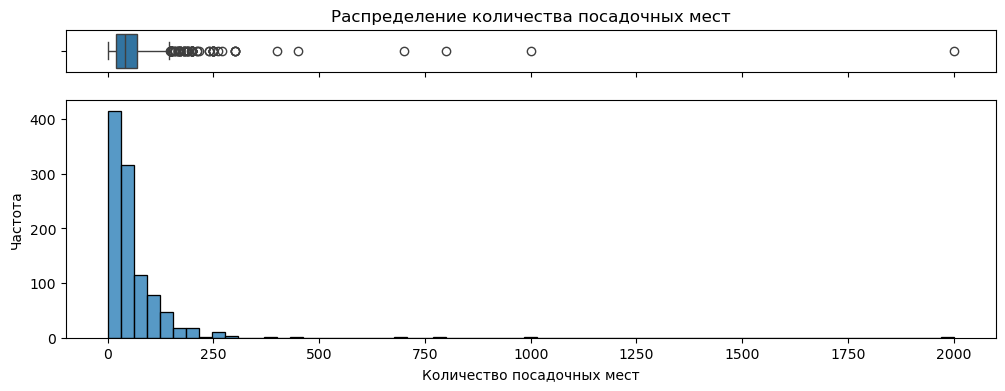

In [25]:
# Построим диаграмму размаха, чтобы проверить выбросы в поле 'seats'
f, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 4)
)

sns.boxplot(x=df['seats'], orient='h', ax=ax_box)
sns.histplot(data=df, x='seats', ax=ax_hist)

ax_box.set(title='Распределение количества посадочных мест')
ax_box.set(xlabel='')
ax_hist.set(xlabel='Количество посадочных мест')
ax_hist.set(ylabel='Частота')
plt.show()

В столбце 'seats' присутствуют несколько аномально крупных значений, однако это могут быть большие банкетные залы. Отрицательные и нулевые значения отсутствуют, медиана равна 40. Центральные 50% данных находятся в интервале от 20 до 70 посадочных мест.

In [26]:
df['avg_bill'].describe()

count    1370.000000
mean      719.181752
std       563.754303
min       130.000000
25%       350.000000
50%       500.000000
75%      1000.000000
max      5000.000000
Name: avg_bill, dtype: float64

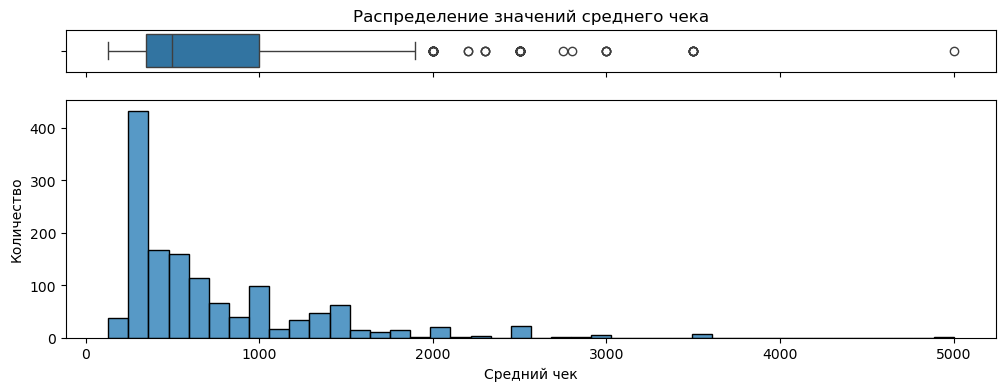

In [27]:
# Построим диаграмму размаха, чтобы проверить выбросы в поле 'avg_bill'
f, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 4)
)

sns.boxplot(x=df['avg_bill'], orient='h', ax=ax_box)
sns.histplot(data=df, x='avg_bill', ax=ax_hist)

ax_box.set(title='Распределение значений среднего чека')
ax_box.set(xlabel='Средний чек')
ax_hist.set(xlabel='Средний чек')
ax_hist.set(ylabel='Количество')
plt.show()

В столбце 'avg_bill' отсутствуют отрицательные и нулевые значения, медиана равна 500 рублей. Центральные 50% данных находятся в интервале от 350 до 1000 рублей. Присутствуют несколько аномально крупных значений, однако это могут быть данные премиального сегмента общепита.

In [28]:
df['rating'].describe()

count    1370.000000
mean        4.137154
std         0.815697
min         1.000000
25%         3.800000
50%         4.400000
75%         4.700000
max         5.000000
Name: rating, dtype: float64

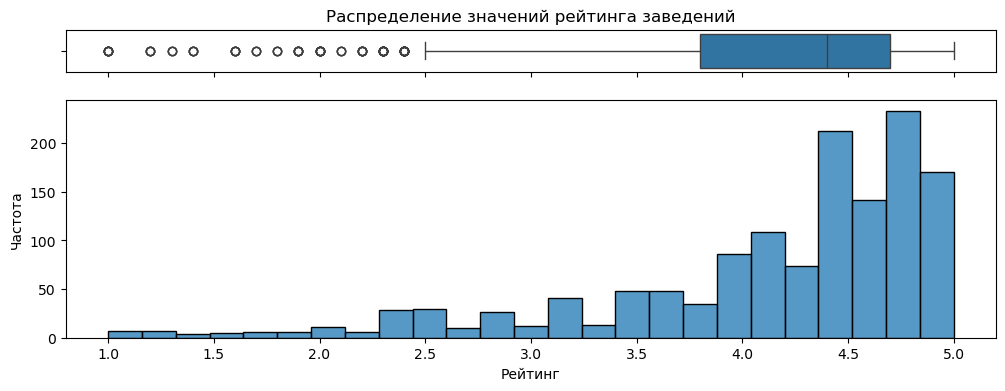

In [29]:
# Построим диаграмму размаха, чтобы проверить выбросы в поле 'rating'
f, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 4)
)

sns.boxplot(x=df['rating'], orient='h', ax=ax_box)
sns.histplot(data=df, x='rating', ax=ax_hist)

ax_box.set(title='Распределение значений рейтинга заведений')
ax_box.set(xlabel='')
ax_hist.set(xlabel='Рейтинг')
ax_hist.set(ylabel='Частота')
plt.show()

В столбце 'rating' отрицательные и нулевые значения отсутствуют, медиана равна 4,4, максимальное значение не превышает 5.0. Центральные 50% данных о рейтинге находятся в интервале от 3,8 до 4,7.

In [30]:
df['review_count'].describe()

count    1370.000000
mean      274.205109
std       576.905090
min         1.000000
25%        22.000000
50%        75.000000
75%       249.000000
max      5426.000000
Name: review_count, dtype: float64

In [31]:
df['photo_count'].describe()

count    1361.000000
mean      112.080086
std       215.504456
min         1.000000
25%        13.000000
50%        42.000000
75%       133.000000
max      4650.000000
Name: photo_count, dtype: float64

При изучении числовых данных отрицательных или нулевых значений не найдено, присутствуют несколько аномально крупных значений, однако они находятся в пределах нормы. Можно сделать вывод, что числовые данные корректны.

## Обогащение данных из внешних источников

### Датафрейм с коммерческими помещениями (commercial_df)

Дополним исходный набор данных сведениями о предложениях аренды и продажи коммерческой недвижимости, пригодной для размещения предприятий общественного питания, с целью анализа актуальных рыночных предложений и перспективных локаций. Указанная информация извлечена из открытых источников платформы «Циан» (сегмент коммерческой недвижимости) по состоянию на май 2026 года и предоставлена в формате .xlsx.

In [32]:
# Загрузим данные
df_rent = pd.read_excel('C:/Users/111/Desktop/Projects/rent.xlsx')
df_sale = pd.read_excel('C:/Users/111/Desktop/Projects/sale.xlsx')

# Определим тип сделки
df_rent['type'] = 'rent'
df_sale['type'] = 'sale'

# Объединим датафреймы
commercial_df = pd.concat([df_rent,df_sale])
commercial_df.info()

<class 'pandas.DataFrame'>
Index: 190 entries, 0 to 61
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID  объявления        190 non-null    int64  
 1   Тип                   190 non-null    str    
 2   Площадь               190 non-null    str    
 3   Возможное назначение  190 non-null    str    
 4   Метро                 189 non-null    str    
 5   Адрес                 190 non-null    str    
 6   Координаты            190 non-null    str    
 7   Этаж                  190 non-null    str    
 8   Высота потолков, м    169 non-null    float64
 9   Цена                  190 non-null    str    
 10  Тип аренды            128 non-null    str    
 11  Телефоны              190 non-null    str    
 12  Описание              190 non-null    str    
 13  Вход                  64 non-null     str    
 14  Ссылка на объявление  190 non-null    str    
 15  type                  190 non-null    st

In [33]:
# Переименуем столбцы
commercial_df = commercial_df[
    ['ID  объявления', 'type', 'Адрес', 'Координаты',
     'Площадь', 'Цена', 'Ссылка на объявление']
].rename(
    columns={
        'ID  объявления': 'id',
        'Адрес': 'address',
        'Координаты': 'coordinates',
        'Площадь': 'area',
        'Цена': 'price',
        'Ссылка на объявление': 'url'
    }
)

In [34]:
# Извлечем числовые значения из столбцов
commercial_df['area'] = commercial_df['area'].str.extract(r'(\d+\.?\d*)').astype(float)
commercial_df['price'] = commercial_df['price'].str.extract(r'(\d+\.?\d*)').astype(float)

# Извлечем долготу и широту из координат
commercial_df[['lat', 'lon']] = (
    commercial_df['coordinates'].str.split(',', expand=True)
)
commercial_df[['lat', 'lon']] = commercial_df[['lat', 'lon']].astype(float)
commercial_df['address'] = (
    commercial_df['address']
    .str.replace('Свердловская область, Екатеринбург, ', '', regex=False)
)
commercial_df = commercial_df.drop('coordinates', axis=1)

In [35]:
# Проверим изменения
commercial_df.info()

<class 'pandas.DataFrame'>
Index: 190 entries, 0 to 61
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       190 non-null    int64  
 1   type     190 non-null    str    
 2   address  190 non-null    str    
 3   area     190 non-null    float64
 4   price    190 non-null    float64
 5   url      190 non-null    str    
 6   lat      190 non-null    float64
 7   lon      190 non-null    float64
dtypes: float64(4), int64(1), str(3)
memory usage: 13.4 KB


In [36]:
commercial_df.head()

,id,type,address,area,price,url,lat,lon
0,315739134,rent,"улица Шефская, 3АД",50.0,40000.0,https://www.cian.ru/rent/commercial/315739134,56.871990,60.660060
1,325679206,rent,"улица Пехотинцев, 2Г",98.0,93100.0,https://www.cian.ru/rent/commercial/325679206,56.873508,60.537167
2,330885088,rent,"улица Михаила Ананьева, 4/2",95.0,133000.0,https://www.cian.ru/rent/commercial/330885088,56.849772,60.609835
3,313848186,rent,"улица Луначарского, 189",443.0,886000.0,https://www.cian.ru/rent/commercial/313848186,56.830339,60.624595
4,318658732,rent,"улица Мраморская, 6",200.0,200000.0,https://www.cian.ru/rent/commercial/318658732,56.784294,60.646136


### Датафрейм с точками интереса (poi_df)

Обогатим датасет данными о точках интереса (остановки транспорта, торговые и бизнес центры, вузы, музеи, галереи, аттракционы, детские игровые комнаты, антикафе, кинотеатры, парки, театры), чтобы проанализировать проходимость вокруг заведений общепита и помещений для открытия. Данные об остановках транспорта выгружены из локальной карты Уральского региона OpenStreetMap, остальные точки интереса - из открытых данных платформы 2ГИС. 

In [37]:
# 1. Базовая директория с CSV-файлами
base_path = Path('C:/Users/111/Desktop/Projects/POI/')

# 2. Словарь для хранения датафреймов
dataframes = {}

# 3. Автоматический обход всех .csv файлов в папке
for file_path in base_path.glob('*.csv'):
    # 3.1. Извлекаем имя файла без расширения (например, 'anticafe')
    file_stem = file_path.stem
    
    # 3.2. Читаем CSV в DataFrame
    poi_df = pd.read_csv(file_path)
    
    # 3.3. Добавляем столбец 'type' со значением, равным имени файла
    poi_df['type'] = file_stem
    
    # 3.4. Сохраняем датафрейм в словарь под ключом-именем файла
    dataframes[file_stem] = poi_df

# 4. Объединяем все датафреймы в одну таблицу
if dataframes:
    poi_df = pd.concat(dataframes.values(), ignore_index=True)
    print(f"Загружено {len(dataframes)} файлов")
else:
    print("CSV-файлы в папке не найдены.")

Загружено 14 файлов


In [38]:
poi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Наименование          1092 non-null   str    
 1   Описание              810 non-null    str    
 2   Адрес                 969 non-null    str    
 3   Комментарий к адресу  666 non-null    str    
 4   Почтовый индекс       1045 non-null   float64
 5   Микрорайон            899 non-null    str    
 6   Район                 894 non-null    str    
 7   Город                 1067 non-null   str    
 8   Округ                 1092 non-null   str    
 9   Регион                1092 non-null   str    
 10  Страна                1092 non-null   str    
 11  Часы работы           1013 non-null   str    
 12  Часовой пояс          1056 non-null   str    
 13  Рейтинг               852 non-null    float64
 14  Количество отзывов    852 non-null    float64
 15  Телефон 1             937 non-nu

In [39]:
# Фильтруем по Екатеринбургу и нужным столбцам
poi_df = poi_df[poi_df['Город'] == 'Екатеринбург']
poi_df = poi_df[['Наименование', 'type', 'Широта', 'Долгота']]
poi_df = poi_df.rename(columns={
    'Наименование': 'name',
    'Широта': 'lat',
    'Долгота': 'lon'
})
print(f'Длина датафрейма после фильтрации: {len(poi_df)} записей')
# Дубликаты
duplicates = poi_df.duplicated().sum()
print(f'Количество найденных дубликатов: {duplicates}')
poi_df = poi_df.drop_duplicates()
# Пропуски
null = poi_df.isna().sum().sum()
print(f'Количество найденных пропусков: {null}')
poi_df = poi_df.dropna()
print(f'Длина итогового датафрейма: {len(poi_df)} записей')

Длина датафрейма после фильтрации: 925 записей
Количество найденных дубликатов: 66
Количество найденных пропусков: 4
Длина итогового датафрейма: 857 записей


In [40]:
# Временная ячейка
transport_df = pd.read_csv('C:/Users/111/Desktop/Projects/transport_poi_ekb.csv')

In [42]:
# Выгружаем данные об остановках транспорта из локальной карты
pbf_path = "C:/Users/111/ural-fed-district-260531.osm.pbf"
ekb_bbox = [60.20, 56.60, 61.00, 57.00]
osm = OSM(pbf_path, bounding_box=ekb_bbox)
filter_dict = {
    'railway': ['station', 'tram_stop'],
    'highway': ['bus_stop'],
    'station': ['subway']
}

In [ ]:
transport_df = osm.get_pois(custom_filter=filter_dict)
print(len(transport_df))
transport_df.info()

In [41]:
transport_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1936 entries, 0 to 1935
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   changeset   1933 non-null   float64
 1   timestamp   1936 non-null   int64  
 2   id          1936 non-null   int64  
 3   tags        1928 non-null   str    
 4   visible     1933 non-null   object 
 5   version     1936 non-null   int64  
 6   lat         1933 non-null   float64
 7   lon         1933 non-null   float64
 8   highway     1534 non-null   str    
 9   lit         321 non-null    str    
 10  name        1842 non-null   str    
 11  ref         31 non-null     str    
 12  service     193 non-null    str    
 13  surface     196 non-null    str    
 14  disused     1 non-null      str    
 15  light_rail  1 non-null      str    
 16  monorail    1 non-null      str    
 17  railway     407 non-null    str    
 18  station     9 non-null      str    
 19  subway      18 non-null     str    
 2

In [42]:
# Распределяем типы
conditions = [
    (transport_df['railway'] == 'station') & (transport_df['station'] == 'subway'),
    (transport_df['railway'] == 'tram_stop') | (transport_df['highway'] == 'bus_stop')
]
choices = ['subway', 'transport_stop']

transport_df['type'] = np.select(conditions, choices, default=None)
transport_df = transport_df[['name','type','lat','lon']]
transport_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1936 entries, 0 to 1935
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    1842 non-null   str    
 1   type    1901 non-null   str    
 2   lat     1933 non-null   float64
 3   lon     1933 non-null   float64
dtypes: float64(2), str(2)
memory usage: 60.6 KB


In [43]:
# Дубликаты по координатам
duplicates_count = transport_df.duplicated(subset=['lon', 'lat']).sum()
print(f'Количество удаляемых дубликатов: {duplicates_count}')
transport_df = transport_df.drop_duplicates(subset=['lon', 'lat'])

# Общее количество пропусков
total_nulls = transport_df.isna().sum().sum()
print(f'Общее количество пропущенных значений: {total_nulls}')
transport_df = transport_df.dropna(subset=['lon', 'lat'])

print(f'Длина итогового датафрейма: {len(transport_df)} записей')

Количество удаляемых дубликатов: 2
Общее количество пропущенных значений: 130
Длина итогового датафрейма: 1933 записей


In [44]:
# Объединяем датафреймы
poi_df = pd.concat([poi_df, transport_df], ignore_index=True)
poi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2790 entries, 0 to 2789
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    2696 non-null   str    
 1   type    2756 non-null   str    
 2   lat     2790 non-null   float64
 3   lon     2790 non-null   float64
dtypes: float64(2), str(2)
memory usage: 87.3 KB


Распределим весовые коэффициенты по шкале от 1 до 5 для точек интереса для целей последующей визуализации.

In [45]:
# Распределяем веса
conditions = [
    poi_df['type'] == 'anticafe',
    poi_df['type'] == 'art',
    poi_df['type'] == 'attraction',
    poi_df['type'] == 'b_centre',
    poi_df['type'] == 'children_game_room',
    poi_df['type'] == 'cinema',
    poi_df['type'] == 'mall',
    poi_df['type'] == 'museum',
    poi_df['type'] == 'music',
    poi_df['type'] == 'park',
    poi_df['type'] == 'quest_room',
    poi_df['type'] == 'station',
    poi_df['type'] == 'subway',
    poi_df['type'] == 'theatre',
    poi_df['type'] == 'transport_stop',
    poi_df['type'] == 'university'
]

# Задаем значения
choices = [2,2,2,4,3,3,5,2,2,3,2,5,5,2,1,5]

# np.select(условия, значения, значение_по_умолчанию)
poi_df['weight'] = np.select(conditions, choices)

In [46]:
# Проверим изменения
poi_df.head()

,name,type,lat,lon,weight
0,Malina Rooms,anticafe,56.837603,60.606619,2
1,Slik Place,anticafe,56.826918,60.636871,2
2,Мяу,anticafe,56.817174,60.613801,2
3,Больше шерсти!,anticafe,56.836526,60.569904,2
4,The box,anticafe,56.836215,60.606975,2


## Расчет дополнительных метрик

Создадим столбец 'category' с распределением заведений по ценовым категориям в зависимости от значения среднего чека.

In [47]:
conditions = [
    df['avg_bill'] < 300,
    (df['avg_bill'] >= 300) & (df['avg_bill'] < 500),
    (df['avg_bill'] >= 500) & (df['avg_bill'] < 1000),
    (df['avg_bill'] >= 1000) & (df['avg_bill'] < 2500),
    df['avg_bill'] >= 2500,
]
choices = ['до 300', '300-500', '500-1000', '1000-2500', 'от 2500']

df['category'] = np.select(conditions, choices, default=None)

Создадим столбец 'coef' с расчетом байесовского среднего для более достоверной оценки на основе рейтинга и количества отзывов с порогом значения первого квартиля (22 отзыва).

In [48]:
c = 22
mean_rating = df['rating'].mean()
w = df['review_count'] / (df['review_count'] + c)
df['coef'] = round(w * df['rating'] + (1 - w) * mean_rating, 2)

Создадим столбец 'is_successful' для определения доли успешных заведений по 80-му процентилю значений рейтинга и количества отзывов. 

In [49]:
# Удаляем строки с пропусками в рейтинге и количестве отзывов
df_valid = df.dropna(subset=['rating', 'review_count']).copy()

# Вычисляем пороги 80-го перцентиля по всему городу
rating_threshold = df_valid['rating'].quantile(0.8)
reviews_threshold = df_valid['review_count'].quantile(0.8)

# Создаём бинарный флаг
df_valid['is_successful'] = (
    (df_valid['rating'] >= rating_threshold) &
    (df_valid['review_count'] >= reviews_threshold)
).astype(int)

success_map = df_valid.set_index('id')['is_successful']
df['is_successful'] = df['id'].map(success_map).fillna(0).astype(int)

Создадим столбцы 'has_wifi', 'has_summer_terrace', 'has_business_lunch', 'has_children_menu', чтобы отметить наличие таких сервисов, как Wi-Fi, летняя терраса, бизнес-ланч и детское меню соответственно.

In [50]:
if 'services' in df.columns:
    wifi_pattern = 'wi-fi|wifi'
    terrace_pattern = (
        'летняя веранда|веранда|терраса|столики на улице'
    )
    lunch_pattern = 'бизнес-ланч|бизнес ланч|ланч'
    children_pattern = 'Детское меню'

    df['has_wifi'] = df['services'].str.contains(
        wifi_pattern, case=False, na=False
    )
    df['has_summer_terrace'] = df['services'].str.contains(
        terrace_pattern, case=False, na=False
    )
    df['has_business_lunch'] = df['services'].str.contains(
        lunch_pattern, case=False, na=False
    )
    df['has_children_menu'] = df['services'].str.contains(
        children_pattern, case=False, na=False
    )
else:
    df['has_wifi'] = False
    df['has_summer_terrace'] = False
    df['has_business_lunch'] = False
    df['has_children_menu'] = False

Создадим столбец 'competitors_1km' с количеством конкурентов для каждого заведения в радиусе 1 км.

In [51]:
# Создаём GeoDataFrame в WGS 84 (широта/долгота)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
)
gdf_m = gdf.to_crs("EPSG:32641")

# Строим буфер 1000 метров вокруг каждой точки
gdf_m['buffer'] = gdf_m.geometry.buffer(1000)

# Пространственное соединение: ищем все точки, попавшие в буфер
joined = gpd.sjoin(
    gdf_m.set_geometry('buffer'),  # геометрия — буфер
    gdf_m[['id', 'geometry']],     # точки конкурентов
    how='left',
    predicate='contains'
)
# Считаем количество попавших точек, исключая саму себя
joined['is_self'] = joined['id_left'] == joined['id_right']
competitors_count = joined[~joined['is_self']].groupby('id_left').size()

df['competitors_1km'] = df['id'].map(competitors_count).fillna(0).astype(int)

Создадим столбец 'cuisine_diversity_score' с показателем разнообразия кухонь в радиусе 1 км для каждого заведения общепита. Этот показатель равен доле заранее заданных 10 «целевых» кухонь на основе топ-10 самых часто встечающихся кухонь в датасете. Результат — от 0.0 (ни одной из целевых кухонь поблизости) до 1.0 (все 10 целевых кухонь доступны в радиусе 1 км). 

In [52]:
df.groupby('cuisine')['id'].count().sort_values(ascending=False).head(10)

cuisine
Восточная       275
Европейская     274
Домашняя        212
Русская         135
Американская     77
Грузинская       58
Итальянская      48
Узбекская        42
Вьетнамская      28
Армянская        27
Name: id, dtype: int64

In [53]:
# 1. Подготовка списка целевых кухонь
target_cuisines = {
    'Американская', 'Русская', 'Восточная', 'Узбекская', 'Европейская',
    'Итальянская', 'Домашняя', 'Грузинская', 'Вьетнамская', 'Армянская'
}
n_target = len(target_cuisines)

# 2. Преобразование столбца cuisine в список кухонь
def parse_cuisine(cuisine_str):
    if pd.isna(cuisine_str):
        return []
    # Разделяем по запятой, удаляем лишние пробелы, возвращаем список
    return [c.strip() for c in cuisine_str.split(',') if c.strip()]

df['cuisine_list'] = df['cuisine'].apply(parse_cuisine)

# 3. Координаты в радианах для BallTree
lat_rad = np.radians(df['latitude'])
lon_rad = np.radians(df['longitude'])
coords = np.column_stack((lat_rad, lon_rad))

# 4. BallTree с метрикой haversine
tree = BallTree(coords, metric='haversine')

# 5. Радиус поиска: 1 км в радианах
earth_radius_km = 6371.0
radius_rad = 1.0 / earth_radius_km

# 6. Поиск соседей в радиусе для каждой точки
indices_radius = tree.query_radius(coords, r=radius_rad)

# 7. Вычисление показателя (исправленная версия)
cuisine_lists = df['cuisine_list'].tolist()  # список списков кухонь для каждой точки

scores = []
for neighbors in indices_radius:
    all_cuisines = set()
    for idx in neighbors:
        all_cuisines.update(cuisine_lists[idx])  # используем сохранённый список
    present = all_cuisines.intersection(target_cuisines)
    score = len(present) / n_target
    scores.append(score)

# 8. Добавляем результат в DataFrame
df['cuisine_diversity_score'] = scores
df.drop('cuisine_list', axis=1, inplace=True)

Рассчитаем для каждого помещения количество заведений общепита в радиусе 500 м и 1 км. 

In [54]:
# Переводим координаты в радианы (функция haversine_distances требует радианы)
df_coords_rad = np.radians(commercial_df[['lat', 'lon']].values)
rest_coords_rad = np.radians(df[['latitude', 'longitude']].values) 

# Вычисляем матрицу расстояний в радианах
distances_rad = haversine_distances(df_coords_rad, rest_coords_rad)

# Переводим радианы в километры, умножая на радиус Земли
distances_km = distances_rad * 6371

# Считаем количество заведений в радиусах
commercial_df['competitors_500m'] = (distances_km <= 0.5).sum(axis=1)
commercial_df['competitors_1km']  = (distances_km <= 1.0).sum(axis=1)

Рассчитаем для каждого помещения средний рейтинг и среднее количество отзывов в радиусе 1 км. 

In [55]:
# Вытаскиваем массивы значений рейтингов и отзывов для всех заведений
ratings = df['rating'].values
review_counts = df['review_count'].values

mean_rating_1km = []
mean_review_count_1km = []

for i in range(distances_km.shape[0]):
    # Исключаем саму точку и берём радиус 1 км
    mask = (distances_km[i] <= 1.0) & (distances_km[i] > 0)
    
    if mask.sum() == 0:
        mean_rating_1km.append(np.nan)
        mean_review_count_1km.append(np.nan)
        continue
    
    r = ratings[mask]
    rc = review_counts[mask]
    
    # Проверяем, есть ли не‑NaN значения
    r_valid = r[~np.isnan(r)]
    rc_valid = rc[~np.isnan(rc)]
    
    mean_rating_1km.append(r_valid.mean() if len(r_valid) > 0 else np.nan)
    mean_review_count_1km.append(rc_valid.mean() if len(rc_valid) > 0 else np.nan)

commercial_df['mean_rating_1km'] = mean_rating_1km
commercial_df['mean_review_count_1km'] = mean_review_count_1km

Создадим столбец 'missing_cuisines_1km' со списком отсутствующих кухонь из топа-10 самых популярных в датасете кухонь для каждого помещения в радиусе 1 км.

In [56]:
# Заданный список кухонь
cuisine_list = [
    'Американская', 'Русская', 'Восточная', 'Узбекская', 
    'Европейская', 'Итальянская', 'Домашняя', 'Грузинская', 
    'Вьетнамская', 'Армянская'
]
# Приводим к нижнему регистру для сравнения
cuisine_list_lower = [c.lower() for c in cuisine_list]

# Функция: извлечь все кухни из строки
def extract_cuisines_set(cuisine_series):
    """Принимает pd.Series со значениями cuisine,""" 
    """возвращает множество уникальных кухонь (нижний регистр)."""
    all_cuisines = set()
    for val in cuisine_series.dropna():   # пропускаем NaN
        # Разбиваем по запятой, чистим пробелы, приводим к нижнему регистру
        parts = str(val).split(',')
        for p in parts:
            c = p.strip().lower()
            if c:
                all_cuisines.add(c)
    return all_cuisines

# Собираем результат для каждого помещения
missing_cuisines_list = []

for i in range(distances_km.shape[0]):          # по всем помещениям (190 строк)
    mask = distances_km[i] <= 1.0               # индексы конкурентов в радиусе 1 км
    if mask.sum() == 0:
        # Нет конкурентов → отсутствуют все кухни из списка
        missing_cuisines_list.append(cuisine_list)   # сохраняем оригинальные названия
    else:
        # Кухни, которые есть у конкурентов
        competitor_cuisines = df.loc[mask, 'cuisine']
        present = extract_cuisines_set(competitor_cuisines)
        
        # Какие кухни из списка отсутствуют?
        missing = [cuisine for cuisine in cuisine_list 
                   if cuisine.lower() not in present]
        missing_cuisines_list.append(missing)

# Добавляем столбец в первый датафрейм
commercial_df['missing_cuisines_1km'] = missing_cuisines_list

Рассчитаем расстояние до метро для каждого помещения и заведения общепита.

In [57]:
# Отбираем станции метро
subway_df = poi_df[poi_df['type'] == 'subway'].copy()

# Подготавливаем координаты в радианах
commercial_df_coords_rad = np.radians(commercial_df[['lat', 'lon']].values)           
subway_coords_rad = np.radians(subway_df[['lat', 'lon']].values)

# Вычисляем матрицу расстояний в радианах, переводим в километры
distances_rad = haversine_distances(
    commercial_df_coords_rad, subway_coords_rad
)
distances_km = distances_rad * 6371  # радиус Земли в км

# Для каждого помещения – минимальное расстояние до метро
commercial_df['dist_to_subway_km'] = distances_km.min(axis=1)

In [58]:
# Подготавливаем координаты в радианах
df_coords_rad = np.radians(df[['latitude', 'longitude']].values)

# Вычисляем матрицу расстояний в радианах, переводим в километры
distances_rad = haversine_distances(df_coords_rad, subway_coords_rad)
distances_km = distances_rad * 6371

# Для каждого заведения – минимальное расстояние до метро
df['dist_to_subway_km'] = distances_km.min(axis=1)

In [59]:
# Проверим изменения
commercial_df.head()

,id,type,address,area,price,url,lat,lon,competitors_500m,competitors_1km,mean_rating_1km,mean_review_count_1km,missing_cuisines_1km,dist_to_subway_km
0,315739134,rent,"улица Шефская, 3АД",50.0,40000.0,https://www.cian.ru/rent/commercial/315739134,56.871990,60.660060,2,5,4.140000,21.400000,"[Американская, Русская, Восточная, Узбекская, ...",2.993540
1,325679206,rent,"улица Пехотинцев, 2Г",98.0,93100.0,https://www.cian.ru/rent/commercial/325679206,56.873508,60.537167,2,10,4.210000,47.299999,"[Русская, Узбекская, Итальянская, Грузинская, ...",4.235785
2,330885088,rent,"улица Михаила Ананьева, 4/2",95.0,133000.0,https://www.cian.ru/rent/commercial/330885088,56.849772,60.609835,10,67,4.244776,441.910461,[],0.683615
3,313848186,rent,"улица Луначарского, 189",443.0,886000.0,https://www.cian.ru/rent/commercial/313848186,56.830339,60.624595,12,71,4.292958,276.464783,[Узбекская],1.388495
4,318658732,rent,"улица Мраморская, 6",200.0,200000.0,https://www.cian.ru/rent/commercial/318658732,56.784294,60.646136,9,20,3.915000,162.800003,"[Узбекская, Итальянская, Домашняя, Грузинская,...",1.710765


## Подготовка данных по административным районам

Загрузим данные по 8 административным районам Екатеринбурга с информацией о площади территории районов и координатами границ. Датасет сформирован на основе данных OpenStreetMap.

In [60]:
district_df = pd.read_csv('C:/Users/111/Desktop/Projects/district_df.csv')

In [61]:
district_df.head(10)

,district,area_km2,coordinates
0,Чкаловский,335.839324,"[[[56.6503296, 60.4116364], [56.6523285, 60.41..."
1,Верх-Исетский,220.118681,"[[[56.8067932, 60.0400772], [56.8069878, 60.04..."
2,Железнодорожный,124.560384,"[[[56.8482399, 60.2707939], [56.848629, 60.270..."
3,Орджоникидзевский,99.932578,"[[[56.9394531, 60.5111237], [56.9336357, 60.51..."
4,Октябрьский,98.539919,"[[[56.833374, 60.8329811], [56.8322792, 60.812..."
5,Кировский,77.614818,"[[[56.833374, 60.8329811], [56.8322792, 60.812..."
6,Академический,44.239103,"[[[56.7658691, 60.4820366], [56.7633476, 60.48..."
7,Ленинский,23.324065,"[[[56.7575264, 60.5030289], [56.756588, 60.504..."


In [62]:
# Объединим с основным датафреймом
full_district_df = df.merge(district_df, on='district', how='left')

In [63]:
# Рассчитаем необходимые метрики, агрегированные по районам
district_stats = full_district_df.groupby('district').agg(
    total_venues=('id', 'count'), # общее количество заведений
    area_km2=('area_km2', 'first'), # площадь района
    avg_bill=('avg_bill', 'mean'), # средний чек
    avg_rating=('rating', 'mean'), # средний рейтинг
    cuisine_diversity=('cuisine', 'nunique'), # количество уникальных кухонь
    avg_subway_dist=('dist_to_subway_km', 'mean'), # среднее расстояние до метро
    parking_ratio=('has_parking', lambda x: x.mean())  # наличие парковки (доля от всех заведений)
).reset_index()
district_stats['density_per_km2'] = district_stats['total_venues'] / district_stats['area_km2'] # плотность заведений в районе
district_stats

,district,total_venues,area_km2,avg_bill,avg_rating,cuisine_diversity,avg_subway_dist,parking_ratio,density_per_km2
0,Академический,71,44.239103,613.239437,4.300000,15,6.350445,0.225352,1.604915
1,Верх-Исетский,173,220.118681,803.289017,4.054914,27,2.464777,0.410405,0.785940
2,Железнодорожный,129,124.560384,568.527132,3.942636,18,2.281149,0.302326,1.035642
3,Кировский,192,77.614818,701.614583,4.137500,23,2.900304,0.171875,2.473754
4,Ленинский,316,23.324065,907.303797,4.343987,33,0.872054,0.367089,13.548239
5,Октябрьский,169,98.539919,790.289941,4.155621,20,3.997701,0.230769,1.715041
6,Орджоникидзевский,140,99.932578,573.642857,4.036428,17,1.465782,0.335714,1.400945
7,Чкаловский,180,335.839324,523.016667,3.988889,19,3.528708,0.200000,0.535971


Нормализуем метрики так, чтобы каждую можно было интерпретировать по принципу «чем выше значение, тем лучше район для открытия», в итоге получаем таблицу с показателями от 0 до 1.

In [64]:
def minmax_scale(series, invert=False):
    mn, mx = series.min(), series.max()
    if mx == mn:  # избегаем деления на 0
        return pd.Series(0.5, index=series.index)
    if invert:
        return 1 - (series - mn) / (mx - mn)
    else:
        return (series - mn) / (mx - mn)

district_stats['norm_density'] = minmax_scale(district_stats['density_per_km2'], invert=True)  # чем меньше плотность, тем лучше -> ближе к 1
district_stats['norm_avg_bill'] = minmax_scale(district_stats['avg_bill'], invert=False)
district_stats['norm_avg_rating'] = minmax_scale(district_stats['avg_rating'], invert=False)
district_stats['norm_cuisine_div'] = minmax_scale(district_stats['cuisine_diversity'], invert=True)  # меньше разнообразие – больше шанс выделиться
district_stats['norm_subway'] = minmax_scale(district_stats['avg_subway_dist'], invert=True)      # меньше расстояние = лучше
district_stats['norm_parking'] = minmax_scale(district_stats['parking_ratio'], invert=False)

radar_df = district_stats[['district',
                           'norm_density',
                           'norm_avg_bill',
                           'norm_avg_rating',
                           'norm_cuisine_div',
                           'norm_subway',
                           'norm_parking']]
radar_df.head(10)

,district,norm_density,norm_avg_bill,norm_avg_rating,norm_cuisine_div,norm_subway,norm_parking
0,Академический,0.917851,0.234780,0.890402,1.000000,0.000000,0.224195
1,Верх-Исетский,0.980790,0.729331,0.279749,0.333333,0.709272,1.000000
2,Железнодорожный,0.961600,0.118428,0.000000,0.833333,0.742790,0.546895
3,Кировский,0.851080,0.464751,0.485521,0.555556,0.629773,0.000000
4,Ленинский,0.000000,1.000000,1.000000,0.000000,1.000000,0.818404
5,Октябрьский,0.909388,0.695504,0.530671,0.722222,0.429459,0.246905
6,Орджоникидзевский,0.933526,0.131741,0.233692,0.888889,0.891624,0.686872
7,Чкаловский,1.000000,0.000000,0.115244,0.777778,0.515067,0.117910


In [65]:
district_df = district_df.merge(radar_df, on='district')

In [66]:
district_df.head(10)

,district,area_km2,coordinates,norm_density,norm_avg_bill,norm_avg_rating,norm_cuisine_div,norm_subway,norm_parking
0,Чкаловский,335.839324,"[[[56.6503296, 60.4116364], [56.6523285, 60.41...",1.000000,0.000000,0.115244,0.777778,0.515067,0.117910
1,Верх-Исетский,220.118681,"[[[56.8067932, 60.0400772], [56.8069878, 60.04...",0.980790,0.729331,0.279749,0.333333,0.709272,1.000000
2,Железнодорожный,124.560384,"[[[56.8482399, 60.2707939], [56.848629, 60.270...",0.961600,0.118428,0.000000,0.833333,0.742790,0.546895
3,Орджоникидзевский,99.932578,"[[[56.9394531, 60.5111237], [56.9336357, 60.51...",0.933526,0.131741,0.233692,0.888889,0.891624,0.686872
4,Октябрьский,98.539919,"[[[56.833374, 60.8329811], [56.8322792, 60.812...",0.909388,0.695504,0.530671,0.722222,0.429459,0.246905
5,Кировский,77.614818,"[[[56.833374, 60.8329811], [56.8322792, 60.812...",0.851080,0.464751,0.485521,0.555556,0.629773,0.000000
6,Академический,44.239103,"[[[56.7658691, 60.4820366], [56.7633476, 60.48...",0.917851,0.234780,0.890402,1.000000,0.000000,0.224195
7,Ленинский,23.324065,"[[[56.7575264, 60.5030289], [56.756588, 60.504...",0.000000,1.000000,1.000000,0.000000,1.000000,0.818404


Построим матрицу «район × кухня» с дополнительными финансовыми индикаторами. Цель — выявить свободные ниши (сочетания района и типа кухни, где нет ни одного заведения) и понять, насколько платёжеспособен район. Идеальная комбинация для открытия нового заведения – is_empty_niche = 1 и is_solvent = 1: свободная ниша в платёжеспособном районе.

In [67]:
# Убираем пропуски, чтобы не плодить комбинации с NaN
districts = df['district'].dropna().unique()
cuisines = df['cuisine'].dropna().unique()

# Создаём MultiIndex из декартова произведения
multi_index = pd.MultiIndex.from_product(
    [districts, cuisines], names=['district', 'cuisine']
)

# Преобразуем в DataFrame
combinations_df = pd.DataFrame(index=multi_index).reset_index()

# Группируем исходные данные по району и кухне
actual_counts = (
    df.dropna(subset=['district', 'cuisine'])
    .groupby(['district', 'cuisine'])
    .size()
    .reset_index(name='actual_count')
)

full_grid = combinations_df.merge(
    actual_counts,
    on=['district', 'cuisine'],
    how='left'
)
full_grid['actual_count'] = full_grid['actual_count'].fillna(0).astype(int)

# Средний чек по городу (единое число)
city_avg = df['avg_bill'].mean()

# Средний чек по каждому району (по всем заведениям)
district_avg = (
    df.dropna(subset=['district'])
    .groupby('district')['avg_bill']
    .mean()
    .reset_index(name='district_avg_bill')
)

# Присоединяем к полной сетке
full_grid = full_grid.merge(district_avg, on='district', how='left')

# Добавляем единое значение городского среднего
full_grid['city_avg_bill'] = city_avg

full_grid['is_empty_niche'] = (full_grid['actual_count'] == 0).astype(int)
full_grid['is_solvent'] = (
    (full_grid['district_avg_bill'] > full_grid['city_avg_bill'])
    .astype(int)
)

cuisine_dataset = full_grid[['district', 'cuisine', 'actual_count',
                           'district_avg_bill', 'city_avg_bill',
                           'is_empty_niche', 'is_solvent']]
cuisine_dataset.head(10)

,district,cuisine,actual_count,district_avg_bill,city_avg_bill,is_empty_niche,is_solvent
0,Ленинский,Восточная,31,907.303797,719.181752,0,1
1,Ленинский,Домашняя,34,907.303797,719.181752,0,1
2,Ленинский,Европейская,69,907.303797,719.181752,0,1
3,Ленинский,Армянская,5,907.303797,719.181752,0,1
4,Ленинский,Кавказская,3,907.303797,719.181752,0,1
5,Ленинский,Итальянская,19,907.303797,719.181752,0,1
6,Ленинский,Турецкая,1,907.303797,719.181752,0,1
7,Ленинский,Американская,15,907.303797,719.181752,0,1
8,Ленинский,Русская,34,907.303797,719.181752,0,1
9,Ленинский,Азербайджанская,2,907.303797,719.181752,0,1


## Выгрузка данных для визуализации

In [68]:
# Выгрузим датафреймы в файлы .csv для дальнейшей визуализации
df.to_csv('C:/Users/111/Desktop/Projects/rest_dataset.csv', index=False)
commercial_df.to_csv('C:/Users/111/Desktop/Projects/commercial_dataset.csv', index=False)
poi_df.to_csv('C:/Users/111/Desktop/Projects/poi_dataset.csv', index=False)
district_df.to_csv('C:/Users/111/Desktop/Projects/district_dataset.csv', index=False)
cuisine_dataset.to_csv('C:/Users/111/Desktop/Projects/cuisine_dataset.csv', index=False)

### Визуализация

Визуализация реализованна на платформе Yandex DataLens: 

https://datalens.yandex/3n8jlk8s8hpom?_no_controls=1&tab=64&_lang=ru&_theme=dark

## Выводы

**Общий анализ рынка общепита Екатеринбурга**

Рынок общественного питания города характеризуется высокой степенью зрелости и насыщенности. Общее количество заведений составляет 1 370 единиц, представляющих 39 различных кухонь. Средний чек по городу зафиксирован на отметке 719 рублей, средний рейтинг – 4,14 балла, что свидетельствует о достаточно высоком уровне сервиса и интенсивной конкурентной борьбе за потребителя.

В структуре предложения наблюдается выраженная поляризация. Лидирующие позиции по количеству объектов занимают восточная (275 заведений), европейская (274) и домашняя (212) кухни, формирующие совместно с русской (135) порядка 65% всего рынка. Остальные направления, включая итальянскую, вьетнамскую, кавказскую и армянскую кухни, представлены существенно скромнее, что указывает на наличие потенциально свободных ниш.

Ценовая сегментация демонстрирует крен в сторону массового потребителя: 65,6% заведений сосредоточены в диапазоне среднего чека 300–1 000 рублей. Наиболее ёмким является сегмент 300–500 рублей (519 объектов), тогда как премиальный сегмент со средним чеком от 2 500 рублей насчитывает лишь 36 объектов (2,6% от общего числа). Это свидетельствует об ограниченном предложении в высоком ценовом диапазоне и одновременно о рисках, связанных с относительно узкой аудиторией с высоким платёжным потенциалом.

В географическом разрезе прослеживается чёткий центро-периферийный градиент. Ленинский район является абсолютным лидером по концентрации заведений (316), величине среднего чека (907 руб.) и среднему рейтингу (4,34). Здесь наблюдается максимальная плотность конкурентов (свыше 250 объектов в радиусе 1 км для наиболее популярных локаций) и практически полное заполнение рыночных ниш. Верх-Исетский район также характеризуется высокой платёжеспособностью (средний чек 803 руб.) и наилучшей обеспеченностью парковками, сохраняя при этом около 29% свободных ниш. Академический, Чкаловский, Орджоникидзевский и Железнодорожный районы отличаются заметно меньшей насыщенностью и более низким средним чеком (от 523 до 613 руб.), однако содержат значительное количество незанятых кулинарных направлений, что при условии корректного ценового позиционирования может быть использовано для относительно безопасного входа на рынок.

Анализ успешных заведений (т.е. объектов с высокими рейтингами и значительным количеством отзывов) позволяет сформировать их усреднённый профиль. Доминирующим типом среди лидеров является ресторан (83 из 135 наиболее успешных объектов) с европейской, грузинской или итальянской кухней и средним чеком в диапазоне 1 000–2 500 рублей. Характерная вместимость успешного ресторана составляет 130–150 посадочных мест. Практически обязательными атрибутами выступают наличие Wi-Fi (81% успешных заведений), предложение бизнес-ланча (63%) и функционирование летней террасы (56%). Таким образом, полноформатный ресторанный формат в среднем ценовом сегменте с акцентом на понятную широкой аудитории кухню демонстрирует наибольшую устойчивость в конкурентной среде Екатеринбурга.

Рынок коммерческой недвижимости дополнительно подтверждает ориентацию на гибкий старт: около 90% предложений приходится на аренду помещений, оптимальная площадь которых для большинства концепций лежит в интервале 80–150 кв. м. Стоимость аренды сильно варьируется в зависимости от близости к метро и плотности конкурентного окружения.

**Рекомендации потенциальным инвесторам**

На основании комплексного анализа рынка можно сформулировать следующие дифференцированные рекомендации.

Для инвесторов с ограниченным бюджетом, ориентированных на минимизацию стартовых рисков, целесообразно рассматривать спальные районы с невысокой плотностью заведений – Орджоникидзевский, Железнодорожный, а также Академический (при условии размещения в зонах с устойчивым пешеходным трафиком). Рекомендуемый формат – кафе или заведение быстрого питания демократичного ценового сегмента (средний чек 300–600 руб.). Приоритетные кухни: домашняя, русская, а также качественный восточный фастфуд, поскольку текущее предложение в данной категории характеризуется низкими рейтингами и оставляет пространство для улучшения сервиса. Оптимальная площадь помещения – 80–120 кв. м. Наличие парковки повысит привлекательность объекта в районах с низкой плотностью метрополитена.

Для реализации премиум-проектов наиболее перспективным выглядит Верх-Исетский район. Он сочетает высокую платёжеспособность аудитории, лучшую в городе обеспеченность парковками и наличие свободных ниш по экзотическим кухням (французская, мексиканская, ливанская, индийская). Средний чек может быть установлен в диапазоне 1 500–2 500 руб. Формат – полноценный ресторан вместимостью не менее 100–120 посадочных мест. Обязательные элементы: бизнес-ланч, летняя терраса, безупречное качество обслуживания.

Инвесторам, нацеленным на экспериментальные или нишевые концепции, следует обратить внимание на зоны с доказанным дефицитом определённых кухонь. Итальянская, вьетнамская, армянская и кавказская кухни на общегородском уровне характеризуются относительно невысоким числом заведений при устойчивом потребительском интересе. При размещении таких проектов в районах со средним или выше среднего чеком (Верх-Исетский, Октябрьский, а также локальные точки вблизи деловых центров Ленинского района) существует потенциал для занятия свободной ниши. При этом следует избегать прямого входа в Ленинский район без уникальной концепции и значительного маркетингового бюджета, поскольку рынок в его границах практически полностью заполнен и отличается наивысшей конкуренцией.

Вне зависимости от выбранной стратегии рекомендуется предусмотреть в концепции обязательные сервисные составляющие, продемонстрировавшие высокую корреляцию с успехом: наличие Wi-Fi, предложение бизнес-ланча и, при наличии технической возможности, обустройство летней террасы. Данные опции существенно повышают привлекательность заведения как для офисной аудитории в будние дни, так и для широкого потока посетителей в тёплое время года.

Таким образом, рынок общественного питания Екатеринбурга представляет собой сочетание высококонкурентного центра с сохраняющимися возможностями для роста на периферии и в слабозаполненных кулинарных нишах. Принятие инвестиционного решения должно базироваться на тщательном соотнесении выбранной концепции с платёжеспособностью локальной аудитории, плотностью конкурентного окружения и инфраструктурными характеристиками конкретной локации.